In [3]:
# Importing libraries

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import os

In [5]:
# Set the dataset path

data_dir = Path("..") /"data" /"raw" /"EuroSAT" /"2750"
data_dir.exists(), data_dir

(True, WindowsPath('../data/raw/EuroSAT/2750'))

In [11]:
# Generating outpur folder

processed_dir = Path("..") /"data" /"processed"
processed_dir.mkdir(parents=True, exist_ok=True)

processed_dir

WindowsPath('../data/processed')

In [13]:
# Defining image size

image_size = (224, 224)

In [15]:
# Creating a preprocessing function

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])

In [17]:
# Testing on the image

sample_class = next(p for p in data_dir.iterdir() if p.is_dir())
sample_image_path = next(sample_class.glob("*"))

img = Image.open(sample_image_path).convert("RGB")
img_tensor = transform(img)

img_tensor.shape

torch.Size([3, 224, 224])

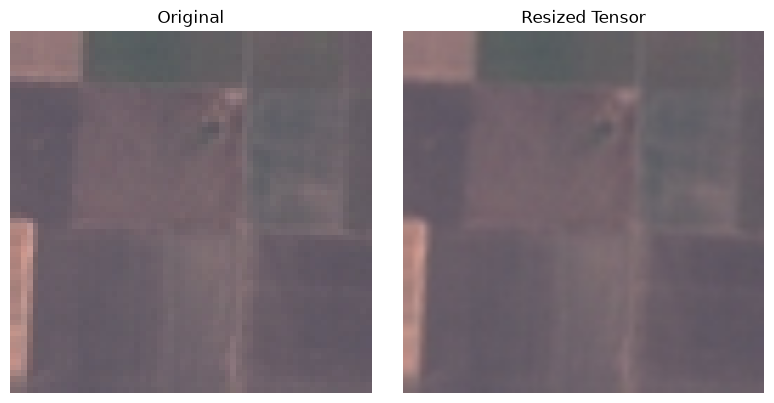

In [19]:
# Display the original and resized image

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_tensor.permute(1, 2, 0))
axes[1].set_title("Resized Tensor")
axes[1].axis("off")

plt.tight_layout()

In [21]:
# Prepare class labels

class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
class_names

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [23]:
# Building a simple image list

image_paths = []
labels = []

for class_name in class_names:
    class_dir = data_dir / class_name
    for img_path in class_dir.glob("*"):
        image_paths.append(img_path)
        labels.append(class_name)

len(image_paths), len(labels)

(27000, 27000)

In [25]:
# Savinf processed info for now

import pandas as pd

df = pd.DataFrame({
    "image_path": [str(p) for p in image_paths],
    "label": labels
})

df.to_csv(processed_dir / "dataset_index.csv", index=False)

df.head()

,image_path,label
0,..\data\raw\EuroSAT\2750\AnnualCrop\AnnualCrop...,AnnualCrop
1,..\data\raw\EuroSAT\2750\AnnualCrop\AnnualCrop...,AnnualCrop
2,..\data\raw\EuroSAT\2750\AnnualCrop\AnnualCrop...,AnnualCrop
3,..\data\raw\EuroSAT\2750\AnnualCrop\AnnualCrop...,AnnualCrop
4,..\data\raw\EuroSAT\2750\AnnualCrop\AnnualCrop...,AnnualCrop
